<a href="https://colab.research.google.com/github/oriol-pomarol/codegeo_workshops/blob/lstm_workshop/10_time_series_with_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10. Time series with LSTM (Long short-term Memory)

In previous workshops, we focused on teaching machine learning models to transform a set of input features into a target prediction. In those settings, each prediction was treated as a mapping from an input vector (features) to an output (target). However, many real-world problems involve data that are inherently ordered. For example, observations may be collected over time. In such situations, the value at a given position is influenced by preceding values. Examples include **climatic time series**, in which present conditions depend on accumulated past dynamics, and language, in which the meaning of a word depends on the words that came before it.

When order matters, models must process data sequentially and retain relevant information from earlier positions. In some cases, **short-term dependencies** are sufficient, while in others, **long-term patterns** (such as seasonal effects) play a crucial role. Capturing dependencies across multiple time scales is therefore essential in many applications. **Recurrent neural networks (RNNs)** introduce the idea of memory by maintaining an internal hidden state that is updated at each step of a sequence. However, standard RNNs often struggle to learn long-term dependencies due to unstable gradient propagation during training.

In this workshop, we will explore **Long Short-Term Memory (LSTM) networks**, which provide a more stable and effective mechanism for preserving information across long sequences.

## LSTM and selective memory 

Understanding Long Short-Term Memory (LSTM) models can be challenging, especially given their multiple internal components and the terminology used to describe their architecture. However, the underlying idea is conceptually simple: LSTMs regulate how information is stored, updated, and used over a sequence.
LSTMs maintain two internal states:

- A hidden state, which contributes directly to predictions,
- A cell state, which serves as a more persistent memory.

<img src="https://d2l.ai/_images/lstm-3.svg" style="width:1000px;">

**Source:** [Zhang et al.](https://d2l.ai/)

The evolution of the cell state is controlled by three mechanisms known as **gates**. These gates determine how information flows through the network at each step of the sequence:
- **Forget gate:** Determines how much of the previous cell state is retained, allowing irrelevant information to be discarded.
- **Input gate:** Determines how much of the current input is incorporated into the cell state.
- **Output gate:** Regulates how much of the cell state influences the hidden state and, consequently, the prediction.

Together, these gated mechanisms provide a controlled and stable way of modelling dependencies across long sequences.

In practice, the relevance of LSTMs becomes clear when working with real sequential data. In the following sections, we will apply an LSTM model to a snow water equivalent (SWE) forecasting problem.

# Snow Water Equivalent (SWE) forecasting

In this notebook, we build a simple forecasting example using daily meteorological data and observed Snow Water Equivalent (SWE) from one station. Our goal is to predict tomorrow’s SWE using information available up to today.

To do this properly, we start by loading the data and removing NaN values. Then we split the data chronologically:
- Earlier years → used for training
- Later years (After August 2003) → used for testing

Because this is a time-series problem, we must respect temporal order. The model should never use future information when learning to forecast.


NaNs in train predictors: 0
NaNs in test predictors: 12
NaNs in train target: 0
NaNs in test target: 0
NaNs in train predictors: 0
NaNs in test predictors: 0
NaNs in train target: 0
NaNs in test target: 0


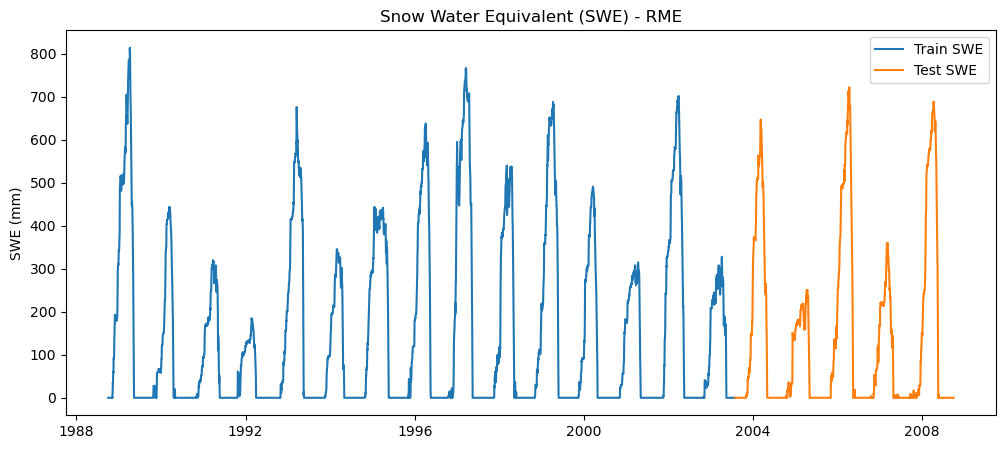

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Reproducibility for workshop
np.random.seed(42)
tf.random.set_seed(42)

# -------------------------------
# 1) Load data
# -------------------------------
station_names = ['cdp', 'oas', 'obs', 'ojp', 'rme', 'sap', 'snb', 'sod', 'swa', 'wfj']
station_data = {}
data_url = "https://raw.githubusercontent.com/oriol-pomarol/codegeo_workshops/lstm_workshop/datasets/snow_forecasting/"

for stn in station_names:
    filename = f"swe_met_insitu_{stn}.csv"
    station_data[stn] = pd.read_csv(data_url + filename, parse_dates=[0], index_col=0)

rme_data = station_data['rme'].copy()

# Train/test split
train_data = rme_data[rme_data.index < '2003-08-01'].copy()
test_data  = rme_data[rme_data.index >= '2003-08-01'].copy()

target_col = "obs_swe"
feature_cols = [c for c in rme_data.columns if c != target_col]

# -------------------------------
# 2) Handle missing values (predictors only)
# -------------------------------

# Sanity check (optional prints)
print("NaNs in train predictors:", train_data[feature_cols].isna().sum().sum())
print("NaNs in test predictors:", test_data[feature_cols].isna().sum().sum())
print("NaNs in train target:", train_data[target_col].isna().sum())
print("NaNs in test target:", test_data[target_col].isna().sum())

# Simple time-series imputation = forward-fill then back-fill.
train_data[feature_cols] = train_data[feature_cols].ffill().bfill()
test_data[feature_cols]  = test_data[feature_cols].ffill().bfill()

# Sanity check
print("NaNs in train predictors:", train_data[feature_cols].isna().sum().sum())
print("NaNs in test predictors:", test_data[feature_cols].isna().sum().sum())
print("NaNs in train target:", train_data[target_col].isna().sum())
print("NaNs in test target:", test_data[target_col].isna().sum())

# -------------------------------
# 3) Plot train/test SWE
# -------------------------------
plt.figure(figsize=(12, 5))
plt.plot(train_data.index, train_data[target_col], label="Train SWE")
plt.plot(test_data.index, test_data[target_col], label="Test SWE")
plt.title("Snow Water Equivalent (SWE) - RME")
plt.ylabel("SWE (mm)")
plt.legend()
plt.show()

Before training the models, we standardise the predictor variables. Neural networks train more efficiently when inputs are on a similar scale, so we fit a `StandardScaler` on the training data only and then apply it to both training and testing sets. This avoids leaking information from the future into the past.

Additionally, to define the forecasting task, we align the data so that today’s predictors are paired with tomorrow’s SWE. In other words, the model learns to use information available up to today to predict tomorrow’s snow water equivalent.

In [122]:
# -------------------------------
# Scale predictors using TRAIN only
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(train_data[feature_cols].values).astype(np.float32)
X_test  = scaler.transform(test_data[feature_cols].values).astype(np.float32)

y_train = train_data[target_col].values.astype(np.float32)
y_test  = test_data[target_col].values.astype(np.float32)

n_features = X_train.shape[1]

# -------------------------------
# Define the forecasting task 
# -------------------------------

# Shifted arrays for forecasting:
#   inputs end at time t, target is y[t+1]
# So we drop last X row and drop first y element to align lengths.
X_train_f = X_train[:-1]
y_train_f = y_train[1:]

X_test_f  = X_test[:-1]
y_test_f  = y_test[1:]

# Timestamps for y_test_f (tomorrow targets)
test_time_f = test_data.index[1:]


The first model is a **Dense neural network**. It looks at the predictor variables from a single day (today) and produces a forecast for the next day. Each prediction is computed independently from the others. The model does not carry information forward in time. Therefore, it treats every day as a separate input–output pair.

The second model is an **LSTM**. We define a variable called `sequence_length`, which specifies how many previous days are provided to the model (in our case, 7). However, the key difference is not just that it receives multiple days of input. The LSTM processes these days one at a time, maintaining an internal state that evolves through time. This internal state acts like a memory of recent conditions, allowing the model to represent how the snowpack evolves from day to day rather than treating each day independently.
In other words, the Dense model makes a prediction from a static snapshot, while the LSTM builds and updates a dynamic representation of the system before making its forecast.

Both models are trained with early stopping to prevent overfitting, and we compare their performance on the test period using RMSE.

In [123]:
# -------------------------------
# Baseline model: Dense (no sequence)
# -------------------------------


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

dense_model = tf.keras.Sequential([
    tf.keras.Input(shape=(n_features,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="relu")
])
dense_model.compile(optimizer="adam", loss="mse")

dense_model.fit(
    X_train_f, y_train_f,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stop]
)

dense_pred = dense_model.predict(X_test_f, verbose=0).flatten()
dense_rmse = np.sqrt(mean_squared_error(y_test_f, dense_pred))
print(f"Dense neural network - RMSE: {dense_rmse:.3f}")


# Use past L days of predictors to predict tomorrow's SWE.
sequence_length = 7

# -------------------------------
# LSTM model: Sequence-aware
# -------------------------------

train_ds = tf.keras.preprocessing.timeseries_dataset_from_array(
    data=X_train_f,
    targets=y_train_f,
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=True
)

test_ds = tf.keras.preprocessing.timeseries_dataset_from_array(
    data=X_test_f,
    targets=y_test_f,
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False
)

lstm_model = tf.keras.Sequential([
    tf.keras.Input(shape=(sequence_length, n_features)),
    tf.keras.layers.LSTM(64,activation="relu"),
    tf.keras.layers.Dense(1,activation="relu")
])

lstm_model.compile(optimizer="adam", loss="mse")


lstm_model.fit(
    train_ds,
    epochs=100,
    validation_data=test_ds,  # OK now because targets are clean
    verbose=0,
    callbacks=[early_stop]
)

lstm_pred = lstm_model.predict(test_ds, verbose=0).flatten()

# Alignment for test targets:
y_test_seq = y_test_f[sequence_length-1:]
time_seq   = test_time_f[sequence_length-1:]

lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_pred))
print(f"LSTM (7-day window) RMSE: {lstm_rmse:.3f}")

Dense neural network - RMSE: 154.788
LSTM (7-day window) RMSE: 124.431


We now compare the forecasts from both models against the observed SWE in the test period.

From the RMSE values computed earlier, we already know that the **LSTM** performs better. This difference in performance can also be observed visually in the plot below. The black line represents the observed SWE, while the coloured lines show the forecasts from each model.

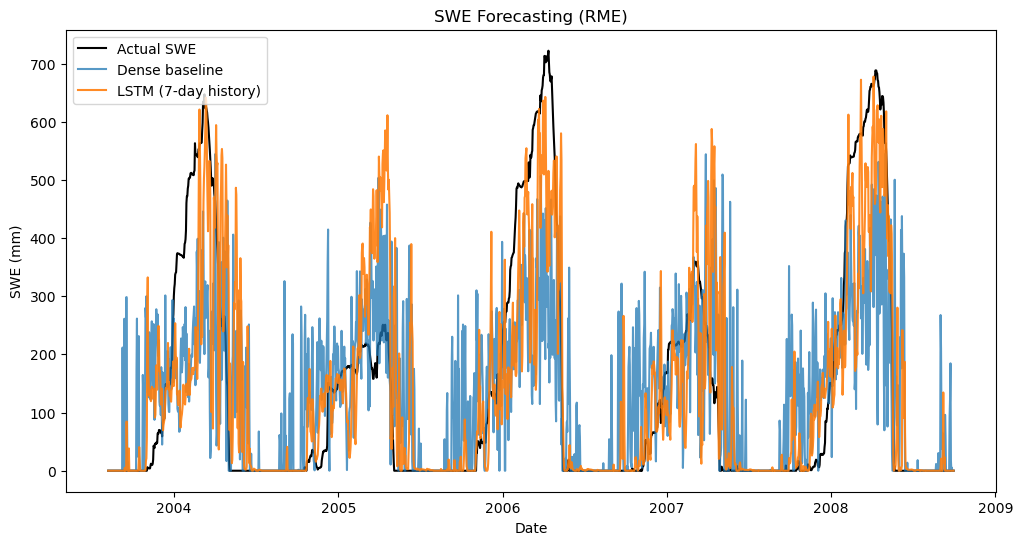

In [124]:
# -------------------------------
# Plot predictions vs actual
# -------------------------------
plt.figure(figsize=(12, 6))
plt.plot(time_seq, y_test_seq, label="Actual SWE", color="black")

# Dense baseline: dense_pred is aligned with y_test_f directly (no window)
# To compare fairly on the same time axis as LSTM, slice dense predictions too:
dense_pred_seq = dense_pred[sequence_length-1:]
plt.plot(time_seq, dense_pred_seq, label="Dense baseline", alpha=0.75)

plt.plot(time_seq, lstm_pred, label="LSTM (7-day history)", alpha=0.9)

plt.title("SWE Forecasting (RME)")
plt.xlabel("Date")
plt.ylabel("SWE (mm)")
plt.legend()
plt.show()

# Old example

In [125]:
# Load the station data
station_names = ['cdp', 'oas', 'obs', 'ojp', 'rme', 'sap', 'snb', 'sod', 'swa', 'wfj']
station_data = {}
data_url = "https://raw.githubusercontent.com/oriol-pomarol/codegeo_workshops/lstm_workshop/datasets/snow_forecasting/"
for stn in station_names:
    filename = f"swe_met_insitu_{stn}.csv"
    station_data[stn] = pd.read_csv(data_url + filename, parse_dates=[0], index_col=0)

In [126]:
# Take the first 15 years as training and the last 5 as testing
rme_data = station_data['rme']
train_data = rme_data[rme_data.index < '2003-08-01']
test_data = rme_data[rme_data.index >= '2003-08-01']

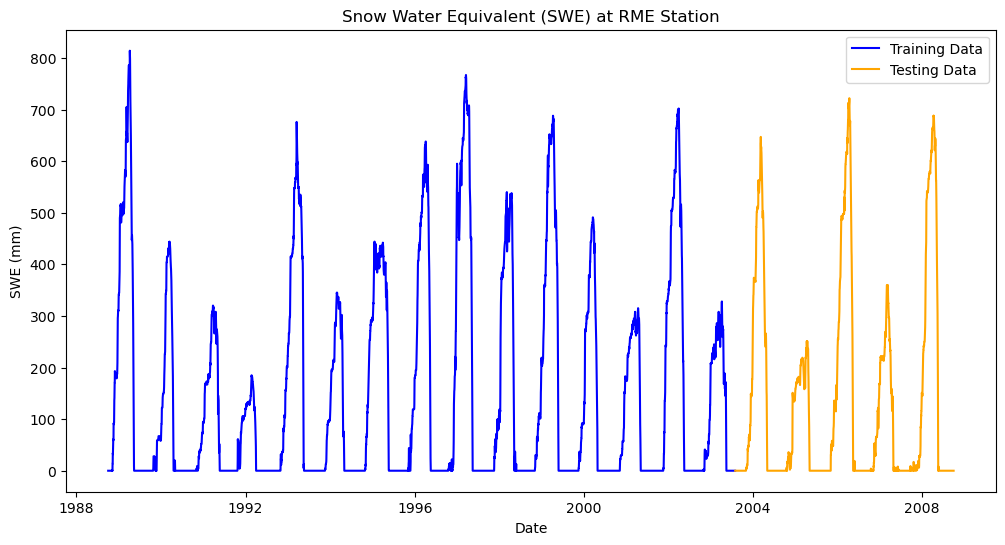

In [127]:
	
# Make a plot of the rme station
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['obs_swe'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data['obs_swe'], label='Testing Data', color='orange')
plt.title('Snow Water Equivalent (SWE) at RME Station')
plt.xlabel('Date')
plt.ylabel('SWE (mm)')
plt.legend()
plt.show()

In [128]:
# Normalize the input features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data.drop(columns=['obs_swe']))
X_test_scaled = scaler.transform(test_data.drop(columns=['obs_swe']))

In [129]:
# Define the number of time steps to look back
sequence_length = 14
n_features = X_train_scaled.shape[1]

# Define the LSTM model
model = tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(sequence_length, n_features)))
model.add(tf.keras.layers.LSTM(64, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='relu'))
model.compile(optimizer='adam', loss='mse')

In [130]:
# Create a time series dataset
train_dataset = tf.keras.preprocessing.timeseries_dataset_from_array(
    data=X_train_scaled,
    targets=train_data['obs_swe'].values,
    sequence_length=sequence_length,
    batch_size=32,
)

# Check the size of the dataset
for batch in train_dataset.take(1):
    inputs, targets = batch
    print(f'Input shape: {inputs.shape}, Target shape: {targets.shape}')

Input shape: (32, 14, 12), Target shape: (32,)


In [131]:
# Train the model
model.fit(train_dataset, epochs=20,verbose=0)

In [132]:
predictions = []
# Predict on test data
for seq_start in range(0, len(X_test_scaled) - sequence_length):
    seq_end = seq_start + sequence_length
    input_seq = X_test_scaled[seq_start:seq_end].reshape((1, sequence_length, n_features))
    prediction = model.predict(input_seq,verbose=0)
    predictions.append(prediction[0][0])
    # print(f'Predicted SWE for day {seq_end}: {prediction[0][0]}')

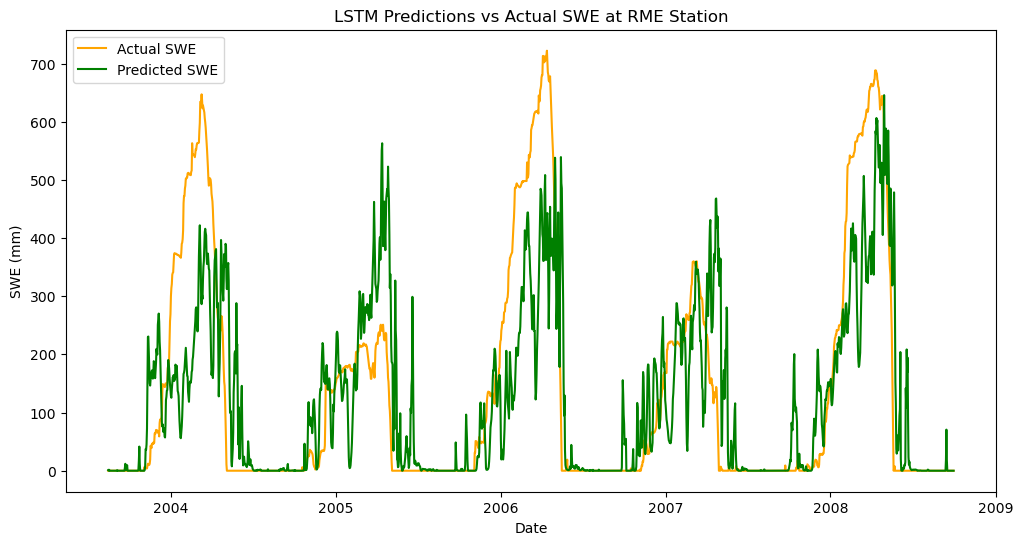

In [133]:
# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(test_data.index[sequence_length:], test_data['obs_swe'][sequence_length:], label='Actual SWE', color='orange')
plt.plot(test_data.index[sequence_length:], predictions, label='Predicted SWE', color='green')
plt.title('LSTM Predictions vs Actual SWE at RME Station')
plt.xlabel('Date')
plt.ylabel('SWE (mm)')
plt.legend()
plt.show()